### Principal Component Analysis
PCA (Principal Component Analysis) is a dimensionality reduction technique used to 
reduce the number of features while preserving most of the important information in the 
dataset. 
It transforms original features into a new set of features called Principal Components. 
Why PCA? 
Suppose a dataset has: 
• Height  
• Weight  
• Age  
• Income  
• Experience  
• Education  
Some features may be highly correlated. 
PCA reduces these features into a smaller number of components while retaining most 
of the variance (information). 
### Principal Components 
Principal Components are new variables created from original features. 
PC1 (First Principal Component) 
• Captures maximum variance in the data.  
• Most important component.  
PC2 (Second Principal Component) 
• Captures remaining variance.  
• Perpendicular to PC1.  
PC3, PC4 ... 
• Capture progressively less variance.  
Example: 
Original Features: 
Height 
Weight 
Age 
Income 
After PCA: 
PC1 
PC2 
The dataset is compressed from 4 dimensions to 2 dimensions.
### Cross Validation
Cross Validation is a technique used to evaluate a machine learning model by training 
and testing it on different subsets of the data. 
Its main purpose is to check how well the model generalizes to unseen data.
### K-Fold Cross validation
In K-Fold Cross Validation, the dataset is divided into K equal parts (folds). 
Example: 
K = 5 
Fold1 
Fold2 
Fold3 
Fold4 
Fold5 
Process 
Iteration 1: 
Test  → Fold1 
Train → Fold2 + Fold3 + Fold4 + Fold5 
Iteration 2: 
Test  → Fold2 
Train → Remaining folds 
Continue until every fold is used once as test data.
### Stratified K-Fold Solution
Stratified K-Fold preserves the class distribution in every fold. 
Example: 
Original Dataset: 
90% Pass 
10% Fail 
Each fold: 
90% Pass 
10% Fail 
Benefits: 
• More reliable evaluation  
• Better for classification problems  
• Handles imbalanced datasets  
### Hyperparameter Tuning
Hyperparameter Tuning is the process of finding the best hyperparameter values for a 
machine learning model to improve performance. 
What are Hyperparameters? 
Hyperparameters are settings that are chosen before training the model.
### Grid Search CV
GridSearchCV tries all possible combinations of hyperparameters and selects the 
combination with the best performance.
### Randomized SEarch CV
RandomizedSearchCV randomly selects a fixed number of parameter combinations 
instead of testing all combinations.
### Optuna
Optuna is a modern hyperparameter optimization library. 
Instead of checking all or random combinations, it learns from previous trials and 
intelligently chooses better hyperparameters.
#### Working 
```text 
Trial 1 
↓ 
Evaluate Model 
↓ 
Learn Results 
↓ 
Suggest Better Parameters 
↓ 
Trial 2 
```
This process continues until the best parameters are found.

Explained Variance Ratio:
[0.72962445 0.22850762]
        PC1       PC2
0 -2.264703  0.480027
1 -2.080961 -0.674134
2 -2.364229 -0.341908
3 -2.299384 -0.597395
4 -2.389842  0.646835


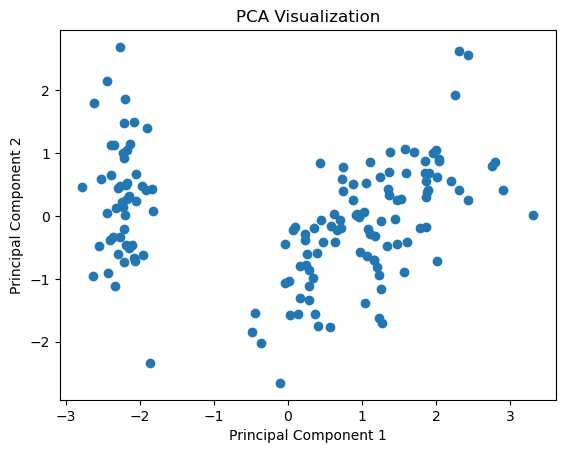

In [2]:
from sklearn.datasets import load_iris
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import pandas as pd
# Load dataset
iris = load_iris()
X = iris.data
# Standardize data
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
# Apply PCA
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)
# Explained Variance Ratio
print("Explained Variance Ratio:")
print(pca.explained_variance_ratio_)
# PCA DataFrame
df = pd.DataFrame(
    X_pca,
    columns=["PC1", "PC2"]
)
print(df.head())
# Scatter Plot
plt.scatter(X_pca[:,0], X_pca[:,1])
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.title("PCA Visualization")
plt.show()

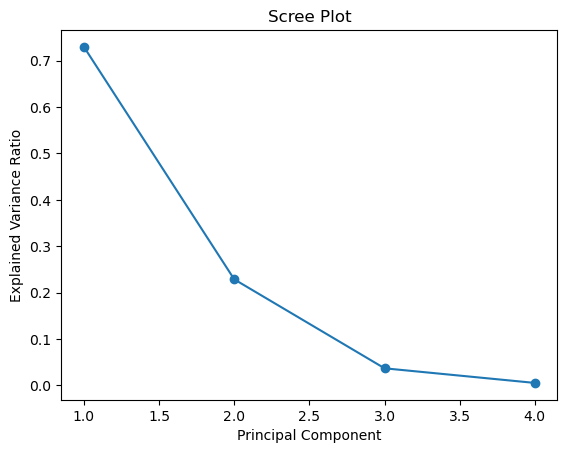

In [5]:
#Scree Plot
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
pca = PCA()
pca.fit(X_scaled)
plt.plot(range(1, len(pca.explained_variance_ratio_)+ 1),pca.explained_variance_ratio_,marker='o')
plt.xlabel("Principal Component")
plt.ylabel("Explained Variance Ratio")
plt.title("Scree Plot")
plt.show()


In [7]:
#K-Fold Cluster
from sklearn.datasets import load_iris
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import KFold, cross_val_score
# Load dataset
iris = load_iris()
X = iris.data
y = iris.target
# Model
model = DecisionTreeClassifier()
# K-Fold
kf = KFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)
scores = cross_val_score(
    model,
    X,
    y,
    cv=kf
)
print("Scores:", scores)
print("Mean Accuracy:", scores.mean())

Scores: [1.         0.96666667 0.93333333 0.93333333 0.93333333]
Mean Accuracy: 0.9533333333333335


In [8]:
#stratiedKFold
from sklearn.datasets import load_iris
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import StratifiedKFold, cross_val_score
# Load dataset
iris = load_iris()
X = iris.data
y = iris.target
# Model
model = DecisionTreeClassifier()
# Stratified K-Fold
skf = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)
scores = cross_val_score(
    model,
    X,
    y,
    cv=skf
)
print("Scores:", scores)
print("Mean Accuracy:", scores.mean())

Scores: [1.         0.96666667 0.93333333 0.96666667 0.9       ]
Mean Accuracy: 0.9533333333333335


In [9]:
!pip install optuna


   ---------------------------------------- 0/4 [Mako]
   -------------------- ------------------- 2/4 [alembic]
   -------------------- ------------------- 2/4 [alembic]
   -------------------- ------------------- 2/4 [alembic]
   -------------------- ------------------- 2/4 [alembic]
   -------------------- ------------------- 2/4 [alembic]
   ------------------------------ --------- 3/4 [optuna]
   ------------------------------ --------- 3/4 [optuna]
   ------------------------------ --------- 3/4 [optuna]
   ------------------------------ --------- 3/4 [optuna]
   ------------------------------ --------- 3/4 [optuna]
   ------------------------------ --------- 3/4 [optuna]
   ------------------------------ --------- 3/4 [optuna]
   ------------------------------ --------- 3/4 [optuna]
   ------------------------------ --------- 3/4 [optuna]
   ------------------------------ --------- 3/4 [optuna]
   ---------------------------------------- 4/4 [optuna]



In [10]:
##GridSearchCV Code
from sklearn.datasets import load_iris
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import GridSearchCV
#Dataset
iris = load_iris()
X = iris.data
y = iris.target
#Model
model = DecisionTreeClassifier()
#Parameter grid
param_grid = {
'max_depth': [2, 3, 4, 5],
'min_samples_split':[2, 4, 6]}
# Grid Search
grid = GridSearchCV(model,param_grid,cv=5,scoring ='accuracy')
grid.fit(X, y)
print("Best Parameters:", grid.best_params_)
print("Best Score:", grid.best_score_)


Best Parameters: {'max_depth': 3, 'min_samples_split': 2}
Best Score: 0.9733333333333334


In [13]:
from sklearn.datasets import load_iris
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import RandomizedSearchCV
# Dataset
iris = load_iris()
X = iris.data
y = iris.target
# Model
model = DecisionTreeClassifier()
# Parameter distribution
param_dist = {
    'max_depth' : [2,3,4,5,6,7,8],
    'min_samples_split' : [2,4,6,8,10]}
random_search = RandomizedSearchCV(
    model,param_distributions = param_dist, n_iter = 6, cv = 5, random_state = 42)
random_search.fit(X,y)
print("Best Parameters:",random_search.best_params_)
print("Best Score:",random_search.best_score_)

Best Parameters: {'min_samples_split': 8, 'max_depth': 4}
Best Score: 0.9666666666666668


In [18]:
##Optuna Basic Code
import optuna
from sklearn.datasets import load_iris
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import cross_val_score
#Dataset
iris = load_iris()
X = iris.data
y = iris.target
# Objective function
def objective(trial):
    max_depth = trial.suggest_int("max_depth",2,10)
    min_samples_split = trial.suggest_int("min_samples_split",2,10)
    model = DecisionTreeClassifier(max_depth = max_depth, min_samples_split = min_samples_split)
    score = cross_val_score(model,X,y,cv=5).mean()
    return score
#Study
study = optuna.create_study(direction="maximize")
study.optimize(objective,n_trials=20)
print("Best Parameters:")
print(study.best_params)
print("Best Score:")
print(study.best_value)

[I 2026-06-12 12:55:28,884] A new study created in memory with name: no-name-9972c37b-fd31-42d5-98e6-d3615622977f
[I 2026-06-12 12:55:28,899] Trial 0 finished with value: 0.9666666666666668 and parameters: {'max_depth': 6, 'min_samples_split': 6}. Best is trial 0 with value: 0.9666666666666668.
[I 2026-06-12 12:55:28,909] Trial 1 finished with value: 0.9666666666666668 and parameters: {'max_depth': 4, 'min_samples_split': 9}. Best is trial 0 with value: 0.9666666666666668.
[I 2026-06-12 12:55:28,922] Trial 2 finished with value: 0.96 and parameters: {'max_depth': 3, 'min_samples_split': 7}. Best is trial 0 with value: 0.9666666666666668.
[I 2026-06-12 12:55:28,933] Trial 3 finished with value: 0.9666666666666668 and parameters: {'max_depth': 5, 'min_samples_split': 3}. Best is trial 0 with value: 0.9666666666666668.
[I 2026-06-12 12:55:28,946] Trial 4 finished with value: 0.9666666666666668 and parameters: {'max_depth': 7, 'min_samples_split': 10}. Best is trial 0 with value: 0.9666666

Best Parameters:
{'max_depth': 6, 'min_samples_split': 6}
Best Score:
0.9666666666666668


In [ ]:
# Deep learning and NLP